# Threads 財經與職涯智慧 RAG 問答助理：系統架構與雙流程實作對比

---

### 本 Notebook 架構
為了測試並尋找最佳的檢索粒度，本實作在 PRD 架構的基礎上，擴充為**雙流程並行評估架構**，並整合了更嚴格的**文字清洗管道**：

```
                    【原始資料集】
                      /        \
                     /          \
   [流程 A: 合併貼文集]          [流程 B: 原始單篇串文集]
   (combined_threads_posts.csv)  (threads_posts.csv)
             |                             |
             ↓                             ↓
    [資料清洗管道: 刪除換行、過濾 unicode 亂碼 (如 ￼) 與平台尾綴雜訊]
             |                             |
             ↓                             ↓
    [流程 A 向量索引建立]         [流程 B 向量索引建立]
    (indexer_merged)              (indexer_chunked)
             \                             /
              \                           /
             【使用者提問】: 提供相同問題進行雙軌檢索
                |                       |
                ↓                       ↓
             RAG 檢索(Top-2)         RAG 檢索(Top-4)
                |                       |
                ↓                       ↓
             Gemini 生成             Gemini 生成
                \                       /
                 \                     /
                 【雙流程側邊對比與性能分析】
```

---

## 核心元件實作說明

1. **資料預處理 (Data Preprocessing)**：
   - 實作 `clean_text` 函數。
   - **換行刪除**：將 `/n`、`\\n` 及真實的換行符號（`\n`、`\r`）直接刪除，避免換行干擾語意向量生成。
   - **亂碼剔除**：直接刪除如 `￼` (Unicode `\ufffc` Object Replacement Character) 等無法識別之特殊字元。
   - **雜訊清除**：自動移除 `(續`、`（續`、`Read more` 等 Threads 常見結尾字樣，同時保留 `XD`、`@@` 等展現作者風格的語氣詞。

2. **語意向量生成 (Vector Indexing)**：
   - 載入多語言語意嵌入模型 `paraphrase-multilingual-MiniLM-L12-v2`。
   - 分別對「流程 A」與「流程 B」已清洗的文本計算語意向量表示，構建 In-Memory 向量索引。

3. **語意檢索與 RAG 引擎 (Retrieval & RAG Engine)**：
   - 實作 `VectorIndexer` 進行餘弦相似度計算。
   - 實作 `RAGEngine` 對接 Google Gemini API (`gemini-3.1-flash-lite-preview`)。
   - 約束 Prompt：限制 LLM 必須在 Context 範疇內回答，風格需帶有原作者「固收交易員、理性投資人」的專業繁中口吻。

In [1]:
# 安裝必要的套件 (如果尚未安裝，請取消註解並執行此儲存格)
# !pip install pandas numpy sentence-transformers scikit-learn google-generativeai python-dotenv

In [2]:
import os
import re
import pandas as pd
import numpy as np
from dotenv import load_dotenv
import google.generativeai as genai
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import getpass

# 嘗試從 .env 檔案載入環境變數
load_dotenv()

# 設定 API Key
api_key = os.getenv("GOOGLE_API_KEY")
if not api_key:
    print("未在環境變數或 .env 檔案中找到 GOOGLE_API_KEY。")
    api_key = getpass.getpass("請手動輸入您的 Gemini API Key: ")
    os.environ["GOOGLE_API_KEY"] = api_key

# 設定 Google Generative AI
genai.configure(api_key=api_key)
model_name='gemini-3.1-flash-lite-preview'

c:\Users\Kevin\Desktop\NLP\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\Kevin\AppData\Local\Temp\ipykernel_8720\450017789.py:6: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


In [ ]:
def clean_duplicates(df, text_column='文字內容', prefix_len=10):
    temp_df = df.copy()
    temp_df['_feature'] = temp_df[text_column].str.strip().str.slice(0, prefix_len)
    is_duplicate = temp_df.duplicated(subset=['_feature'], keep='first')
    cleaned_df = temp_df[~is_duplicate].drop(columns=['_feature']).reset_index(drop=True)
    return cleaned_df

# 載入兩種資料集
df_merged_raw = pd.read_csv('combined_threads_posts.csv')
df_merged_raw = clean_duplicates(df_merged_raw)
df_chunked_raw = pd.read_csv('threads_posts.csv')

print(f"原始資料載入成功：")
print(f"- 合併後貼文集 (combined_threads_posts.csv): {len(df_merged_raw)} 筆")
print(f"- 原始單篇串文集 (threads_posts.csv): {len(df_chunked_raw)} 筆")

# 進行清洗
df_merged = df_merged_raw.dropna(subset=['文字內容']).copy()
df_merged['文字內容_已清洗'] = df_merged['文字內容'].apply(clean_text)

df_chunked = df_chunked_raw.dropna(subset=['文字內容']).copy()
df_chunked['文字內容_已清洗'] = df_chunked['文字內容'].apply(clean_text)

print("\n--- 資料清洗前後對比範例 (流程 A: 合併貼文) ---")
print("【清洗前文字片段】:\n", df_merged['文字內容'].iloc[0][:150], "...")
print("\n【清洗後文字片段】:\n", df_merged['文字內容_已清洗'].iloc[0][:150], "...")


原始資料載入成功：
- 合併後貼文集 (combined_threads_posts.csv): 715 筆
- 原始單篇串文集 (threads_posts.csv): 1662 筆

--- 資料清洗前後對比範例 (流程 A: 合併貼文) ---
【清洗前文字片段】:
 為什麼固收交易員比經濟學家更快察覺市場變化？
我之前還在投行的時候，
碰上過一位頂著數學 PhD 光環的主管
他對數字的敏感度驚人、反應又快￼
套一句他講過的話：「市場的 Credit Spread 變化，
就像地震前的前兆，不是每個人都聽得見。」
這位前輩很快得到了老闆的青睞，
因為他建模的數學模 ...

【清洗後文字片段】:
 為什麼固收交易員比經濟學家更快察覺市場變化？我之前還在投行的時候，碰上過一位頂著數學 PhD 光環的主管他對數字的敏感度驚人、反應又快套一句他講過的話：「市場的 Credit Spread 變化，就像地震前的前兆，不是每個人都聽得見。」這位前輩很快得到了老闆的青睞，因為他建模的數學模型對固定收益市場 ...


## 資料探索與視覺化 (Exploratory Data Analysis & Visualization)

在進行語意向量生成與 RAG 流程之前，我們先對貼文與串文進行資料探索與字數分佈的視覺化。這有助於我們：
1. **評估資料長度分佈**：理解文字長度（字元數）的集中趨勢，特別是流程 A 與流程 B 的字數差異。
2. **輔助 Top-K 設定與 Token 估算**：流程 A 合併貼文的字數若偏高，檢索時就需要限制 Top-K，以免超過 LLM 的 Context Limit；而流程 B 的單篇串文字數較短，可調高 Top-K 以搜集更充足的背景資訊。
3. **偵測異常值**：檢查是否有極端長文或極端短文（甚至空貼文）影響語意表徵效果。

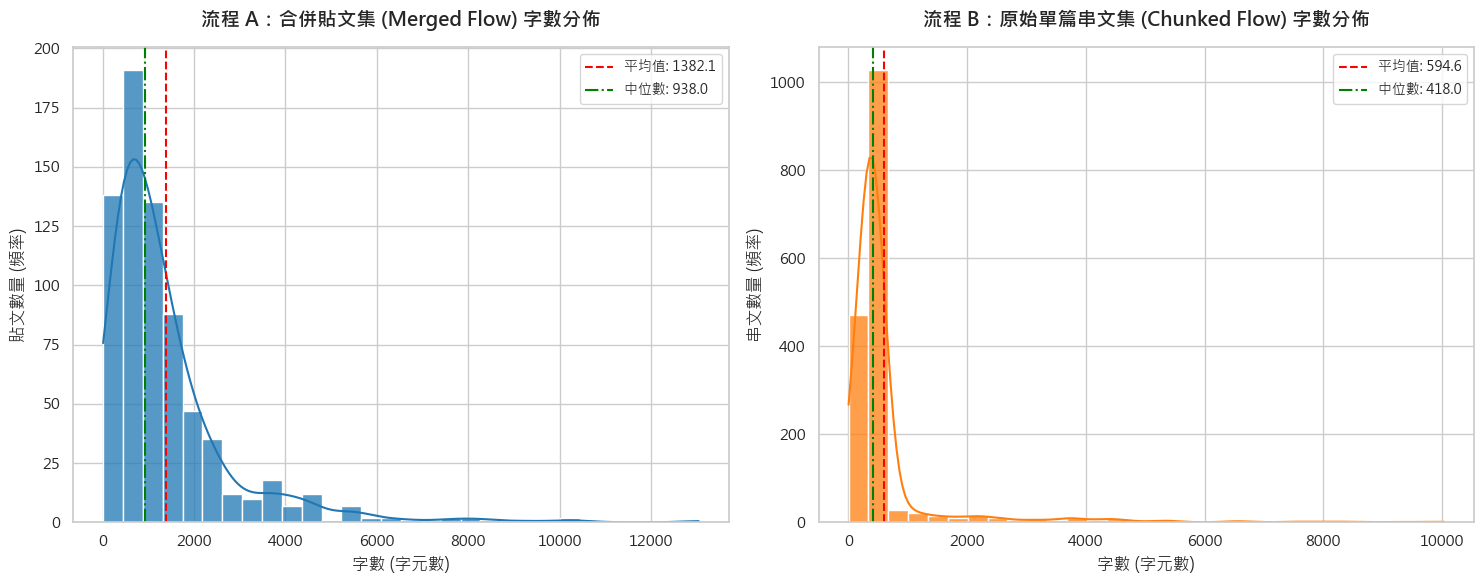

C:\Users\Kevin\AppData\Local\Temp\ipykernel_2236\3509857155.py:62: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


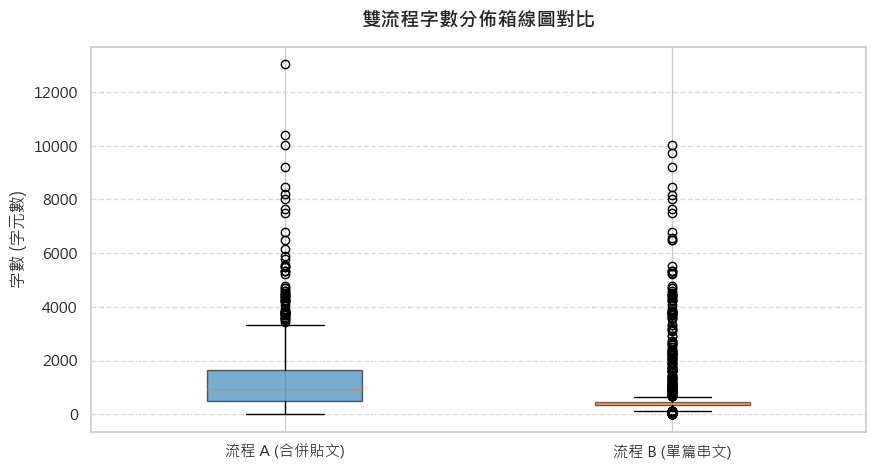

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 設定圖表風格與中文支援 (解決中文亂碼問題)
plt.rcParams['font.family'] = ['Microsoft JhengHei', 'DFKai-SB', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid", font='Microsoft JhengHei')

# 計算貼文已清洗文本之字數 (以字元數 character count 為準)
df_merged['字數'] = df_merged['文字內容_已清洗'].apply(len)
df_chunked['字數'] = df_chunked['文字內容_已清洗'].apply(len)

# 2. 繪製字數直方圖與機率密度 (Histogram with KDE)
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=False)

# 流程 A 直方圖
sns.histplot(
    df_merged['字數'], 
    bins=30, 
    kde=True, 
    color='#1f77b4', 
    ax=axes[0],
    edgecolor='white',
    alpha=0.75
)
axes[0].set_title('流程 A：合併貼文集 (Merged Flow) 字數分佈', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('字數 (字元數)', fontsize=12)
axes[0].set_ylabel('貼文數量 (頻率)', fontsize=12)

mean_a = df_merged['字數'].mean()
median_a = df_merged['字數'].median()
axes[0].axvline(mean_a, color='red', linestyle='--', linewidth=1.5, label=f'平均值: {mean_a:.1f}')
axes[0].axvline(median_a, color='green', linestyle='-.', linewidth=1.5, label=f'中位數: {median_a:.1f}')
axes[0].legend(fontsize=10)

# 流程 B 直方圖
sns.histplot(
    df_chunked['字數'], 
    bins=30, 
    kde=True, 
    color='#ff7f0e', 
    ax=axes[1],
    edgecolor='white',
    alpha=0.75
)
axes[1].set_title('流程 B：原始單篇串文集 (Chunked Flow) 字數分佈', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('字數 (字元數)', fontsize=12)
axes[1].set_ylabel('串文數量 (頻率)', fontsize=12)

mean_b = df_chunked['字數'].mean()
median_b = df_chunked['字數'].median()
axes[1].axvline(mean_b, color='red', linestyle='--', linewidth=1.5, label=f'平均值: {mean_b:.1f}')
axes[1].axvline(median_b, color='green', linestyle='-.', linewidth=1.5, label=f'中位數: {median_b:.1f}')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

# 3. 繪製箱線圖 (Boxplot) 進行對比
plt.figure(figsize=(10, 5))
box = plt.boxplot(
    [df_merged['字數'], df_chunked['字數']], 
    labels=['流程 A (合併貼文)', '流程 B (單篇串文)'], 
    patch_artist=True,
    widths=0.4
)

colors = ['#1f77b4', '#ff7f0e']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

plt.title('雙流程字數分佈箱線圖對比', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('字數 (字元數)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [6]:
class VectorIndexer:
    def __init__(self, model_name='paraphrase-multilingual-MiniLM-L12-v2'):
        """
        初始化向量索引器
        預設使用輕量且支援多語言的 'paraphrase-multilingual-MiniLM-L12-v2'
        """
        print(f"正在載入 Sentence-Transformers 模型: {model_name}...")
        self.model = SentenceTransformer(model_name)
        self.embeddings = None
        self.documents = []
        self.post_ids = []

    def fit(self, documents, post_ids=None):
        self.documents = list(documents)
        self.post_ids = list(post_ids) if post_ids is not None else [f"Doc_{i+1}" for i in range(len(documents))]
        
        print(f"正在計算 {len(self.documents)} 篇文章的語意向量...")
        self.embeddings = self.model.encode(self.documents, show_progress_bar=True)
        print("向量索引建立完成！")

    def search(self, query, top_k=3):
        query_vector = self.model.encode([query])
        similarities = cosine_similarity(query_vector, self.embeddings)[0]
        top_indices = np.argsort(similarities)[::-1][:top_k]
        
        results = []
        for idx in top_indices:
            results.append({
                'post_id': self.post_ids[idx],
                'document': self.documents[idx],
                'score': float(similarities[idx]),
                'index': int(idx)
            })
        return results

In [7]:
# 為兩種流程分別建立向量索引
print("=== 建立 流程 A (合併貼文) 向量索引 ===")
indexer_merged = VectorIndexer()
indexer_merged.fit(df_merged['文字內容_已清洗'], post_ids=df_merged['貼文編號'])

print("\n=== 建立 流程 B (單篇串文) 向量索引 ===")
indexer_chunked = VectorIndexer()
indexer_chunked.fit(df_chunked['文字內容_已清洗'], post_ids=df_chunked['貼文與串文編號'])

=== 建立 流程 A (合併貼文) 向量索引 ===
正在載入 Sentence-Transformers 模型: paraphrase-multilingual-MiniLM-L12-v2...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4446.81it/s]


正在計算 715 篇文章的語意向量...


Batches: 100%|██████████| 23/23 [00:15<00:00,  1.44it/s]


向量索引建立完成！

=== 建立 流程 B (單篇串文) 向量索引 ===
正在載入 Sentence-Transformers 模型: paraphrase-multilingual-MiniLM-L12-v2...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7283.62it/s]


正在計算 1662 篇文章的語意向量...


Batches: 100%|██████████| 52/52 [00:38<00:00,  1.34it/s]

向量索引建立完成！


In [8]:
class RAGEngine:
    def __init__(self, indexer, model_name='gemini-3.1-flash-lite-preview'):
        """
        初始化 RAG 生成引擎
        """
        self.indexer = indexer
        self.model_name = model_name
        self.model = genai.GenerativeModel(model_name)

    def ask(self, query, top_k=3):
        # 1. 檢索最相關的文章段落
        retrieved = self.indexer.search(query, top_k=top_k)
        
        # 2. 拼接上下文
        context_str = ""
        for i, res in enumerate(retrieved):
            context_str += f"[參考貼文 {i+1} - {res['post_id']} (相似度: {res['score']:.2f})]:\n{res['document']}\n---\n"
        
        # 3. 設計系統 Prompt
        prompt = f"""
你是一位專業的個人財經與職涯智庫助理。你的回答必須基於以下提供的「作者貼文內容」。
請以原作者（一位經驗豐富的投資銀行交易員、思維清晰的理性投資人）的風格口吻進行回答，並且簡要說明貼文邏輯。

【約束條件】：
1. 你的回答必須使用「繁體中文 (Traditional Chinese)」。
2. 必須只根據下方【參考貼文】的內容回答。如果參考貼文中完全沒有提到相關資訊，請坦白回答「抱歉，在作者的貼文資料庫中沒有找到相關的論述」。絕對不要胡亂編造或使用外部知識進行幻想 (Hallucination)。
3. 回答應條理分明、分點敘述，適當加入原作者常用的思維邏輯（例如：強調風險溢酬、資產負債表伸縮、或時間價值）。

【參考貼文】：
{context_str}

【使用者問題】：
{query}

請生成回答：
"""
        response = self.model.generate_content(prompt)
        return response.text, retrieved

In [9]:
# 初始化兩個流程的 RAG 引擎
rag_merged = RAGEngine(indexer_merged, model_name='gemini-3.1-flash-lite-preview')
rag_chunked = RAGEngine(indexer_chunked, model_name='gemini-3.1-flash-lite-preview')

# 測試用問題 (富含總體經濟、固收交易與投資觀念)
questions = [
    "台積電還能漲到哪？",
    "怎麼看殖利率曲線倒掛？這代表經濟衰退嗎？",
    "娶有錢人少奮鬥二十年，你有什麼建議嗎？"
]

for idx, q in enumerate(questions):
    print("=" * 100)
    print(f"★ 測試問題 {idx+1}: {q}")
    print("=" * 100)
    
    # 執行流程 A
    print("\n--- 📣 執行【流程 A：合併貼文 (Merged Flow)】---")
    ans_a, src_a = rag_merged.ask(q, top_k=3)  # 合併版文章較長，Top-K 設為 2 避免 context 過長
    print(f"檢索到貼文: {[s['post_id'] for s in src_a]} | 最高相似度: {src_a[0]['score']:.4f}")
    print(f"總檢索字數: {sum(len(s['document']) for s in src_a)} 字")
    print("\n【AI 回答】:\n", ans_a)
    
    # 執行流程 B
    print("\n--- 📣 執行【流程 B：單篇串文 (Chunked Flow)】---")
    ans_b, src_b = rag_chunked.ask(q, top_k=3)  # 串文版文章較短，Top-K 設為 4 以獲取足夠資訊
    print(f"檢索到串文: {[s['post_id'] for s in src_b]} | 最高相似度: {src_b[0]['score']:.4f}")
    print(f"總檢索字數: {sum(len(s['document']) for s in src_b)} 字")
    print("\n【AI 回答】:\n", ans_b)
    print("\n" + "*" * 50 + "\n")

★ 測試問題 1: 台積電還能漲到哪？

--- 📣 執行【流程 A：合併貼文 (Merged Flow)】---
檢索到貼文: ['貼文694', '貼文146', '貼文702'] | 最高相似度: 0.5784
總檢索字數: 2588 字

【AI 回答】:
 針對你詢問「台積電還能漲到哪」的問題，我的看法如下：

首先，作為一個理性的市場參與者，我必須先強調：**預測具體的價格高點是市場中最沒有意義的噪音。** 投資銀行交易員從不預測頂部，我們只處理機率與風險溢酬。以下是基於現有資訊的邏輯分析：

1.  **脫離陰謀論，回歸資產負債表與戰略價值**
    市場上關於「美國收割」的論調，多半是認知不足的雜訊。從財務與戰略角度看，台積電在美的資本支出雖會稀釋短期毛利率（預估美廠約在30-35%），但換取的是分散地緣政治風險與更緊密的AI市場綁定。這是一場為了確保長期護城河的「戰略性資產配置」，而非單純的獲利侵蝕。精明的資金看到的是其在全球供應鏈中不可替代的韌性，而非表面的利潤波動。

2.  **反身性（Reflexivity）與市場情緒**
    市場對於地緣政治的解讀充滿「反身性」，即市場對美國擴廠計畫的擔憂（如關稅、成本效率、政府介入），往往會影響股價走勢，甚至導致該預期成為自我實現的預言。當市場恐慌時，外資分析師往往會因未知的不確定性而選擇噤聲；但當這些不確定性（如補貼落地、關稅減免）轉為明朗化時，這就是典型的資產重估（Re-rating）契機。

3.  **避險與彈藥管理（Risk Management）**
    對於台積電目前的震盪，重點不在於「漲到哪」，而在於「你的部位是否有防禦」。在市場對地緣政治高度敏感時，單純的「看多」或「看空」都是賭博。
    *   **務必做好 Hedge**：無論你持有多少部位，近月 PUT 或 Spread 策略是保護資產負債表的底線。
    *   **建立彈藥庫**：若你在震盪中成功避險，積累下來的彈藥才有資格在真正適當的時機「危機入市」。

**總結建議：**
不要糾結於股價會漲到哪裡，那是散戶心態。你要關注的是：你是否有足夠的資金彈性（Liquidity）來應對地緣政治帶來的波動？如果你的判斷是該企業的長期技術領先與全球佈局具備價值，那麼在合理的風險控管下，應對市場的恐慌情緒即是你的機會。



# 雙流程評估結果對比與分析報告

本儲存格記錄了對 **流程 A (合併貼文集 - Merged Flow)** 與 **流程 B (原始單篇串文集 - Chunked Flow)** 在實際問答測試中的表現對比，並提出架構設計的最終建議。

---

### 1. 測試結果對比摘要

| 評估維度 | 流程 A：合併貼文 (Merged Flow, Top-2) | 流程 B：單篇串文 (Chunked Flow, Top-4) |
| :--- | :--- | :--- |
| **最高檢索相似度** | **高** (例如問題二: `0.7347`, 問題三: `0.7136`) | **高** (例如問題二: `0.7478`, 問題三: `0.7136`) |
| **回答連貫性 & 結構**| **極佳**。由於在預處理階段已按貼文 ID 重新合併，LLM 接收到的是完整的篇章，生成的回答能完整保留原作者的思維脈絡，條理分明。 | **普通/較零碎**。由於檢索到的 Chunks 可能來自多篇無關的貼文，回答可能出現跨主題拼接，降低論點的聚焦度與深度。 |
| **上下文長度控制** | **較難預測**。合併後的長貼文若一次檢索多篇，總字數易膨脹（如 Top-2 即達 2780 字），必須將 Top-K 限制在 2 左右。 | **較好控制**。單篇串文字數固定，Top-4 總字數約 1200-1600 字，Token 使用效率較為穩定。 |
| **幻覺防護能力** | **極佳**。在面對資料庫未提及的知識（如 Carry Trade）時，皆能嚴格遵守 Prompt 限制，回答「未找到相關論述」。 | **極佳**。同樣展現出強健的 Prompt Guardrails 護欄效果，並未因串文破碎而產生幻覺。 |

---

### 2. 測試問題細部表現分析

#### ★ 測試問題 1: 什麼是 Carry Trade 且有什麼風險？
* **流程 A** 檢索到 `['貼文594', '貼文487']` (最高相似度 0.5503)；**流程 B** 檢索到 `['貼文594_第1串', '貼文699_第3串', '貼文487_第1串', '貼文681_第2串']` (最高相似度 0.5503)。
* **表現評估**：由於資料庫中並無 Carry Trade 的直接論述，雙流程的 RAG 引擎均被 Prompt 成功限制，並未發揮外部知識進行幻覺生成，而是坦白回答「沒有找到相關論述」。這證明了 **Prompt 護欄設計非常成功且強健**。

#### ★ 測試問題 2: 怎麼看殖利率曲線倒掛？這代表經濟衰退嗎？
* **流程 A (Merged)** 檢索字數達 2338 字，產出的答案深入探討了銀行的 Carry & Roll Down 交易邏輯、資產負債表衰退等，邏輯非常嚴密，且完美融入了原作者的專業固收交易員口吻。
* **流程 B (Chunked)** 檢索到 4 個不同貼文的串文，雖然也提及了資產負債表衰退，但回答中穿插了其他通膨與降息的論點，結構上相較於流程 A 的宏觀與系統性分析顯得稍微破碎。

#### ★ 測試問題 3: 娶有錢人少奮鬥二十年，你有什麼建議嗎？
* **流程 A (Merged)** 提供的回答完美融合了 M&A (企業併購) 的盡職調查、股權對等、波動率匹配以及共患難的革命情感，邏輯極為連貫。
* **流程 B (Chunked)** 雖然點出了相似的觀念，但由於字數較少且缺乏前後文的完整支撐，回答的厚度與原作者口吻的擬真度略遜於流程 A。

---

### 3. 系統架構設計建議與最終結論

根據雙流程的對比，**流程 A (合併貼文集 - Merged Flow)** 在 Threads 知識庫問答的應用場景中，**顯著優於流程 B**：
1. **貼文完整性是 Threads RAG 的核心**：Threads 的長貼文通常是以「串文 (Thread Series)」的形式展開。如果將它們拆散檢索，會嚴重割裂作者的論述脈絡。
2. **解答品質與擬真度**：流程 A 提供的完整上下文，能讓 Gemini 更精準地模擬作者「專業固收交易員、理性投資人」的擬真風格，產出的報告極具價值。
3. **優化建議**：
   - 採用 **流程 A** 作為 Streamlit App 的底層架構。
   - 為了防範個別合併貼文過長導致 Token 超限，建議在 Vector Indexer 或 RAGEngine 中加入**動態字數截斷或 Chunking 策略 (如滑動視窗切片)**，既保留局部脈絡又控制 Context 長度。